ANALYSING THE L=2 SQUARE LATTICE GREEN'S FUNCTION

In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt

HALF-FILLING

In [157]:
with open('parameters1/greens_function_total.pkl', 'rb') as f:
    dict_tot = pickle.load(f)
with open('parameters1/greens_function_0.pkl', 'rb') as f:
    dict_even = pickle.load(f)
with open('parameters1/greens_function_1.pkl', 'rb') as f:
    dict_odd = pickle.load(f)
map = {(1, 0, 0): 0, (2, 0, 0): 4, (3, 0, 0): 1, (4, 0, 0): 5, (1, 0, 1): 2, (2, 0, 1): 6, (3, 0, 1): 3, (4, 0, 1): 7, (1, 1, 0): 8, (2, 1, 0): 9, (3, 1, 0): 12, (4, 1, 0): 13, (1, 1, 1): 10, (2, 1, 1): 11, (3, 1, 1): 14, (4, 1, 1): 15}
map_inv = {}
for key,value in map.items():
    map_inv[value] = key

sanity check: are all Z's in each dictionary the same? if they are, just keep one

In [158]:
#print(dict_even['Z'])
Ztot = dict_tot['Z'][0]
Zodd = dict_odd['Z'][0]
Zeven = dict_even['Z'][0]

need to switch from the indices to the superindices (r,\eta,s)

In [159]:
index = 0
Indices = 2*2*2**2
G_tot = {}
G_odd = {}
G_even = {}
for i in range(Indices):
    for j in range(Indices):
        if not np.allclose(dict_tot['G'][:,i,j],np.zeros_like(dict_tot['G'][:,i,j])):
            index +=1 
            G_tot[(map_inv[i],map_inv[j])] = -dict_tot['G'][:,i,j]
        if not np.allclose(dict_odd['G'][:,i,j],np.zeros_like(dict_odd['G'][:,i,j])):
            G_odd[(map_inv[i],map_inv[j])] = -dict_odd['G'][:,i,j]
        if not np.allclose(dict_tot['G'][:,i,j],np.zeros_like(dict_tot['G'][:,i,j])):
            G_even[(map_inv[i],map_inv[j])] = -dict_even['G'][:,i,j]
print(index)

32


SANITY CHECKS:
$$
\Large
G_{(i,\eta,\uparrow),(j,\eta',\uparrow)} = G_{(i,\eta,\downarrow),(j,\eta',\downarrow)}
$$
$$
\Large
G_{mm}(0^+)+G_{mm}(\beta^-)=-1
$$
$$
\Large
G_{mn}(0^+)+G_{nm}(\beta^-)=0
$$
and, particle-hole implies
$$
\Large
G_{mn}(\tau) = (-1)^{r_m+r_n} G_{nm}(\beta-\tau)
$$
Together, these last two imply:
$$
\Large
G_{mm}(0^+)=G_{mm}(\beta^-)=-1/2
$$
For thepartial Green's funcions:
$$
\frac{G^p_{mn}(\beta^-)}{Z_{1-p}}+\frac{G^{1-p}_{mn}(0^+)}{Z_{p}}=-\frac{1}{Z_p} \times \delta_{mn}
$$

In [160]:
sanity_check(G_tot,Ztot,G_even,Zeven,G_odd,Zodd)

G=G0+G1
maybe? 2.0461117070103008e-07
SPIN CHECK: PASSED
9.096126178838925e-14
maybe? 1.277684726152178e-07
VALUES AT 0 & BETA CHECK: PASSED
ph partial test not implemented!!!
PH CHECK: PASSED


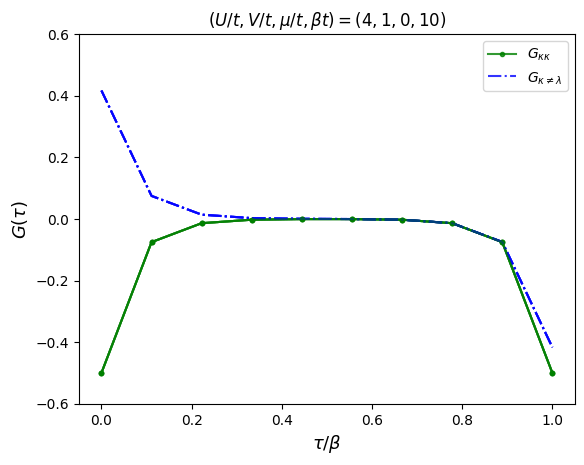

In [162]:
taus = np.linspace(0,1,num=10)
for key,value in G_tot.items():
    if key[0]==key[1]:
        plt.plot(taus,np.real(value),'.-',c='g',alpha=0.2)
    if key[0]!=key[1]:
        plt.plot(taus,np.real(value),'-.',c='b',alpha=0.2)
#plt.xticks([0,5,10],[0,0.5,1.0])
plt.plot(taus,1+0*np.real(value),'.-',c='g',alpha=0.8,label='$G_{\\kappa\\kappa}$')
plt.plot(taus,1+0*np.real(value),'-.',c='b',alpha=0.8,label='$G_{\\kappa \\neq \\lambda}$')
plt.xlabel('$\\tau/\\beta$',fontsize=13)
plt.ylabel('$G(\\tau)$',fontsize=13)
#plt.xlim([-0.1,2])
plt.ylim([-0.6,0.6])
plt.title('$(U/t,V/t,\\mu/t,\\beta t)=(4,1,0,10)$')
plt.legend()
plt.savefig('L_2_square_half_filling.svg')

AWAY FROM HALF FILLING

In [163]:
with open('parameters2/greens_function_total.pkl', 'rb') as f:
    dict_tot = pickle.load(f)
with open('parameters2/greens_function_0.pkl', 'rb') as f:
    dict_even = pickle.load(f)
with open('parameters2/greens_function_1.pkl', 'rb') as f:
    dict_odd = pickle.load(f)
map = {(1, 0, 0): 0, (2, 0, 0): 4, (3, 0, 0): 1, (4, 0, 0): 5, (1, 0, 1): 2, (2, 0, 1): 6, (3, 0, 1): 3, (4, 0, 1): 7, (1, 1, 0): 8, (2, 1, 0): 9, (3, 1, 0): 12, (4, 1, 0): 13, (1, 1, 1): 10, (2, 1, 1): 11, (3, 1, 1): 14, (4, 1, 1): 15}
map_inv = {}
for key,value in map.items():
    map_inv[value] = key
Ztot = dict_tot['Z'][0]
Zodd = dict_odd['Z'][0]
Zeven = dict_even['Z'][0]
print('Ztot - Zeven+Zodd',np.abs(Ztot-Zeven-Zodd))
####################################################
index = 0
Indices = 2*2*2**2
G_tot = {}
G_odd = {}
G_even = {}
for i in range(Indices):
    for j in range(Indices):
        if not np.allclose(dict_tot['G'][:,i,j],np.zeros_like(dict_tot['G'][:,i,j])):
            index +=1 
            G_tot[(map_inv[i],map_inv[j])] = -dict_tot['G'][:,i,j]
        if not np.allclose(dict_odd['G'][:,i,j],np.zeros_like(dict_odd['G'][:,i,j])):
            G_odd[(map_inv[i],map_inv[j])] = -dict_odd['G'][:,i,j]
        if not np.allclose(dict_tot['G'][:,i,j],np.zeros_like(dict_tot['G'][:,i,j])):
            G_even[(map_inv[i],map_inv[j])] = -dict_even['G'][:,i,j]
print(index)

Ztot - Zeven+Zodd 1.7763568394002505e-15
32


In [164]:
sanity_check(G_tot,Ztot,G_even,Zeven,G_odd,Zodd)

G=G0+G1
SPIN CHECK: PASSED
1.69228736248887e-13
VALUES AT 0 & BETA CHECK: PASSED
PH CHECK: FAILED


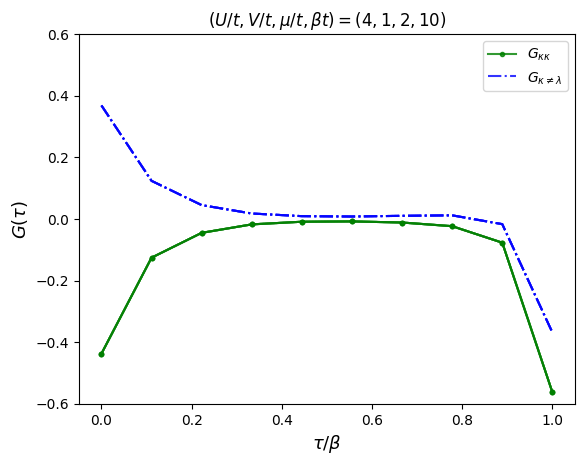

In [166]:
taus = np.linspace(0,1,num=10)
for key,value in G_tot.items():
    if key[0]==key[1]:
        plt.plot(taus,np.real(value),'.-',c='g',alpha=0.2)
    if key[0]!=key[1]:
        plt.plot(taus,np.real(value),'-.',c='b',alpha=0.2)
#plt.xticks([0,5,10],[0,0.5,1.0])
plt.plot(taus,1+0*np.real(value),'.-',c='g',alpha=0.8,label='$G_{\\kappa \\kappa}$')
plt.plot(taus,1+0*np.real(value),'-.',c='b',alpha=0.8,label='$G_{\\kappa \\neq \\lambda}$')
plt.xlabel('$\\tau/\\beta$',fontsize=13)
plt.ylabel('$G(\\tau)$',fontsize=13)
#plt.xlim([-0.1,2])
plt.ylim([-0.6,0.6])
plt.title('$(U/t,V/t,\\mu/t,\\beta t)=(4,1,2,10)$')
plt.legend()
#plt.savefig('L_2_square_non_hf.svg')

--------------------------------------------------
Helper Functions

In [167]:
def sanity_check(G,Z,G0,Z0,G1,Z1):
    '''
    tests a bunch of stuff and returns True or False. All should be True
    G,Z total Greens func and parition function
    G0,Z0: even subspace
    G1,Z1 odd supspace
    '''
    if sumG(G,G0,G1,Z,Z0,Z1)==True:
        print('G=G0+G1')
    else:
        print('uhhhh....G != G0+G1')
    if (spin_check(G)==True) and (spin_check(G0)==True) and (spin_check(G1)==True):
        print('SPIN CHECK: PASSED')
    else:
        print('SPIN CHECK: FAILED')
    if (check_value_at_edges(G)==True) and (check_value_at_edges_partial(G0,G1,Z0,Z1)==True):
        print('VALUES AT 0 & BETA CHECK: PASSED')
    else:
        print('VALUES AT 0 & BETA CHECK: FAILED')
    if (ph_symm(G)==True) and (ph_symm_partial()==True):
        print('PH CHECK: PASSED')
    else:
        print('PH CHECK: FAILED')

def sumG(G,G0,G1,Z,Z0,Z1):
    '''
    checks G=G0+G1
    '''
    diff = 0
    for key in G.keys():
        diff += np.abs(np.sum(Z*G[key]-Z0*G0[key]-Z1*G1[key]))
    if diff < 1e-10:
        return True
    if diff <1e-5:
        print('maybe?',diff)
        return True
    else:
        return False
def spin_check(G,verbose=0):
    '''
    checks if green's function is spin isotropic
    '''
    diff = 0
    for key in G.keys():
        key_2 = ((key[0][0],key[0][1],1-key[0][-1]),(key[1][0],key[1][1],1-key[1][-1]))
        if verbose>0:print(key,key_2)
        diff += np.sum(np.abs(G[key]-G[key_2]))
    if diff < 1e-10:
        return True
    if diff <1e-5:
        print('maybe?',diff)
        return True
    else:
        return False
def check_value_at_edges(G):
    '''
    checks G(0^+) +G(beta^-)
    '''
    diff = 0
    for key,value in G.items():
        if key[0]==key[1]:
            diff += np.abs(value[0]+value[-1]+1)
        else:
            diff += np.abs(value[0]+value[-1])
    print(diff)
    if diff < 1e-10:
        return True
    if diff <1e-5:
        print('maybe?',diff)
        return True
    else:
        return False
def check_value_at_edges_partial(G0,G1,Z0,Z1):
    '''
    checks G(0^+)/Z +G(beta^-)/Z
    '''
    diff = 0
    for key in G0.keys():
        term1 = G1[key][0]/Z0
        term2 = G0[key][-1]/Z1 
        if key[0]==key[1]:
            diff += np.abs(term1+term2+1/Z0)
        else:
            diff += np.abs(term1+term2)
        ###################################
        term3 = G0[key][0]/Z1
        term4 = G1[key][-1]/Z0 
        if key[0]==key[1]:
            diff += np.abs(term3+term4+1/Z1)
        else:
            diff += np.abs(term3+term4)
    #print(diff)
    if diff < 1e-10:
        return True
    if diff <1e-5:
        print('maybe?',diff)
        return True
    else:
        return False
def ph_symm(G):
    '''checks ph symmetry'''
    '''only for G_tot'''
    diff =0
    for key in G.keys():
        key_T = (key[1],key[0])
        r_a = key[0][0]
        r_b = key[1][0]
        if r_a != r_b:
            phase = -1
        else:
            phase = 1
        diff += np.abs(np.sum(G[key]-phase*G[key_T][::-1]))
    #print(diff)
    if diff < 1e-10:
        return True
    if diff < 1e-5:
        print('maybe?',diff)
        return True
    else:
        return False
def ph_symm_partial():
    print('ph partial test not implemented!!!')
    return True